**Mutational signatures: 6 class and trinuc context graphs (run RStudio code first)**

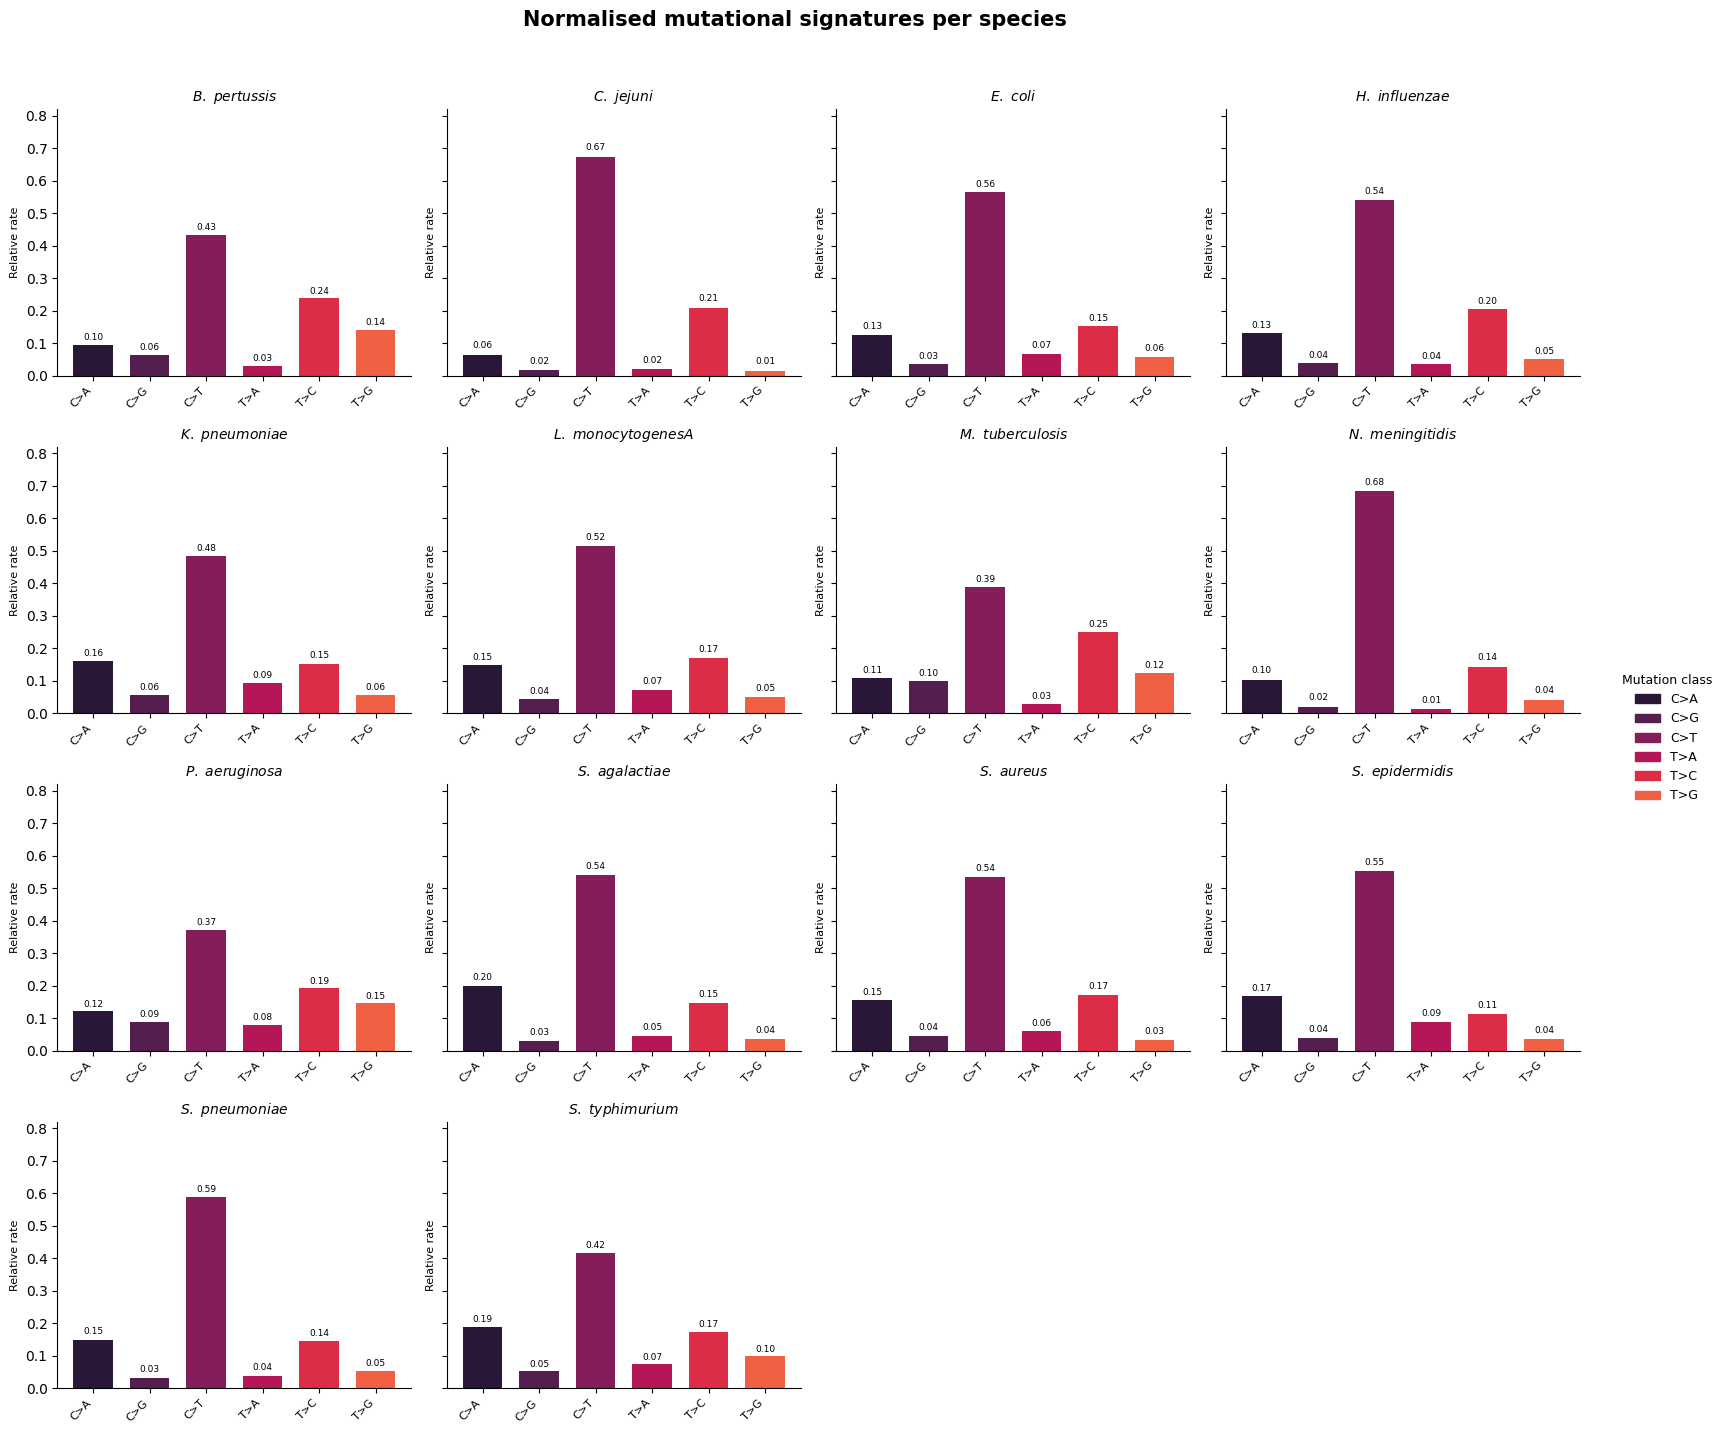

TRINUCLEOTIDE ENRICHMENT
Saved: trinuc_enrichment_combined.csv
Saved: trinuc_cross_species_consistency.csv


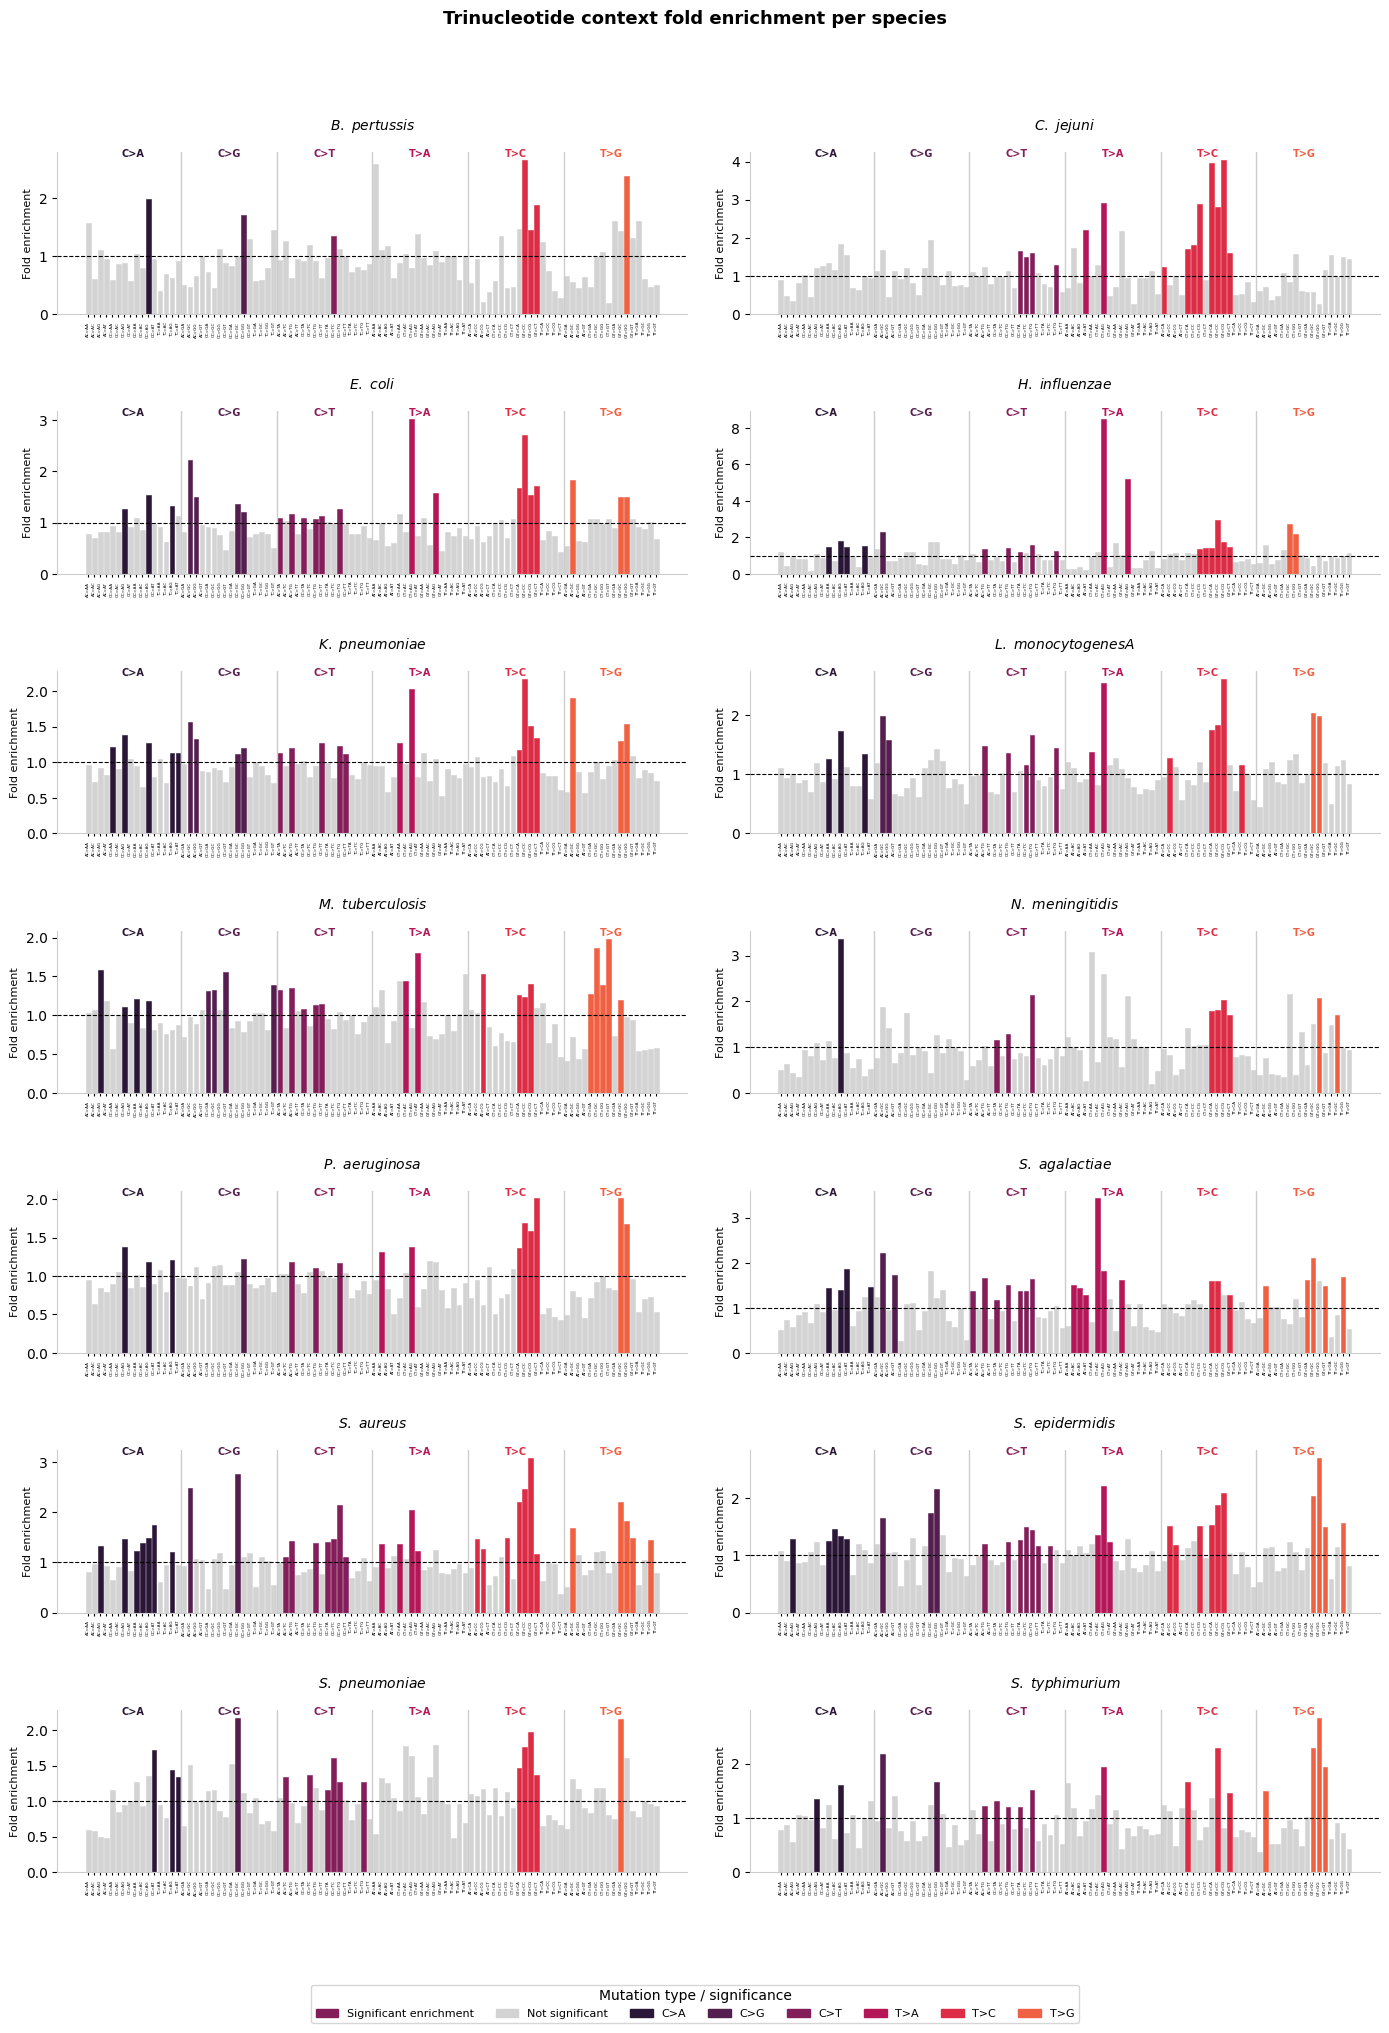

Saved: trinuc_enrichment_96.png


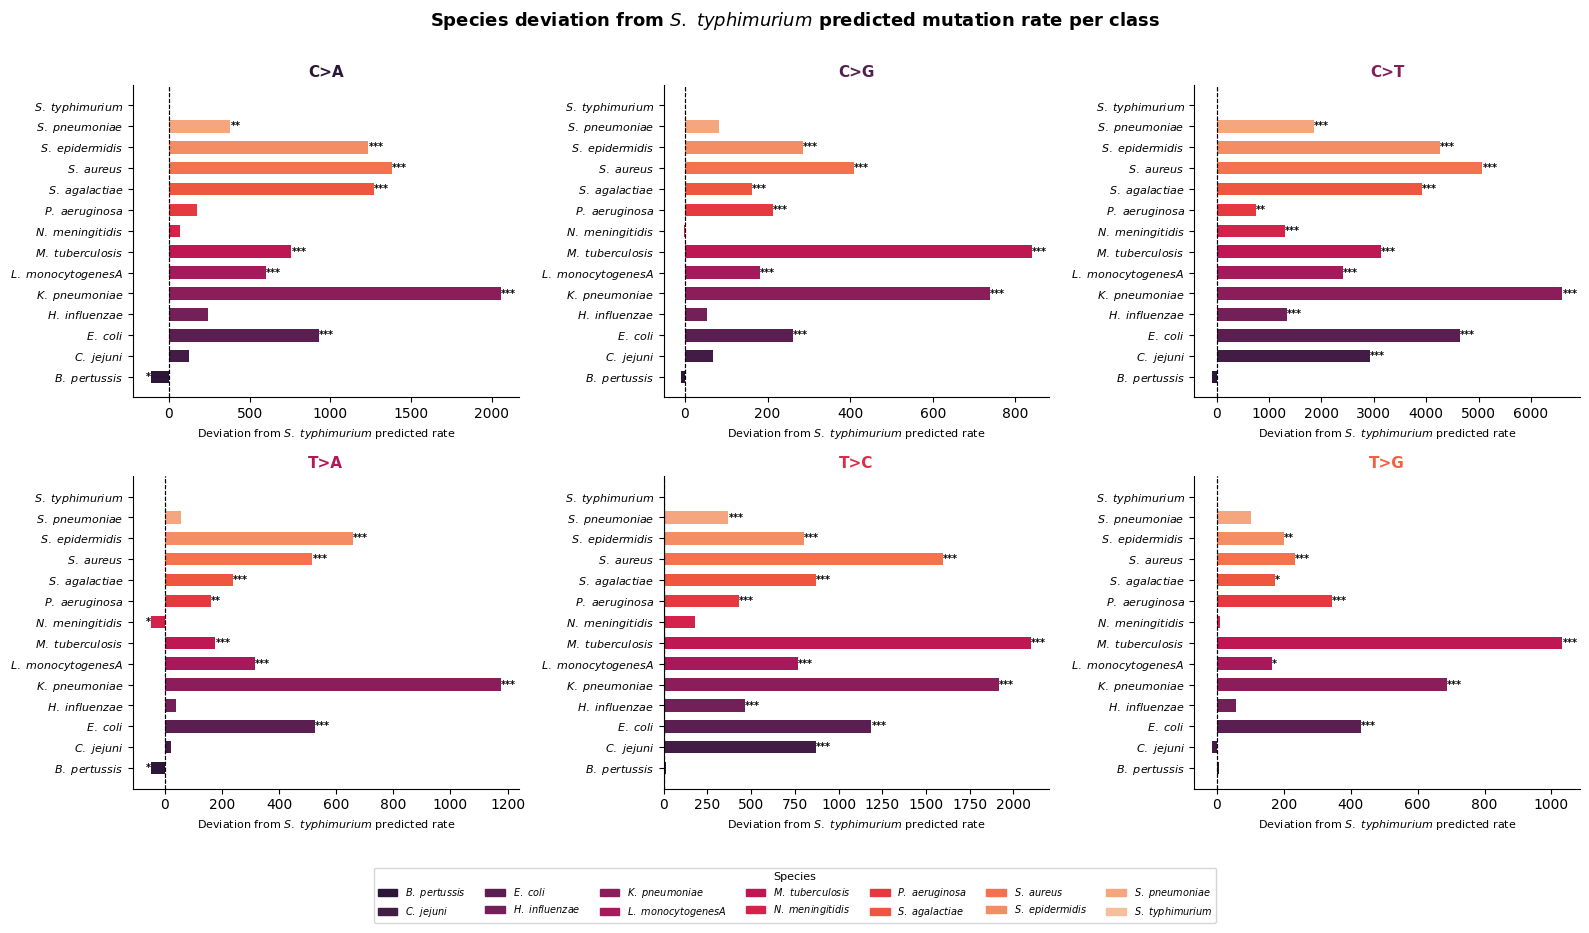

Saved: nb_deviation_by_class.png


In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# define paths
base_folder   = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/"
)
mut_file      = os.path.join(base_folder, "mutation_summary_final_c.csv")
trinuc_file   = os.path.join(base_folder, "trinucleotide_context.csv")
output    = os.path.join(base_folder, "charts", "mut_signatures")
contrasts_csv = os.path.join(output, "model1_species_contrasts.csv")
pred_path     = os.path.join(output, "model1_predicted_rates.csv")

# consistent colour scheme
MUTATION_TYPES = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
PALETTE        = sns.color_palette("rocket", 8)
MUT_COLOURS    = dict(zip(MUTATION_TYPES, PALETTE))

# gets trinuc contexts, extracts middle part to associate local context with mutation class
BASES          = ["A", "C", "G", "T"]

trinuc_context = []
for mut in MUTATION_TYPES:
    for five in BASES:
        for three in BASES:
            trinuc_context.append(f"{five}[{mut}]{three}")

trinuc_to_mut = {t: t[2:5] for t in cosmic_96}

DPI               = 300
REFERENCE_SPECIES = "styphimurium"

###########
# Plot 1, defines rate, 
df = pd.read_csv(mut_file)
df["rate"] = df["no_mutations"] / df["opportunities"]

# sums rates in new table, fill gaps 
pivot = df.pivot_table(
    index="species", columns="mutation_class",
    values="rate", aggfunc="sum"
).fillna(0)

# divides row by total to sum to 1, makes sure classes are in right order with correct sign
pivot.columns = pivot.columns.str.replace("->", ">", regex=False)  # add this
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm = pivot_norm.reindex(columns=MUTATION_TYPES, fill_value=0)

#find height needed for graph, extracts names and colours for plots 
global_max = pivot_norm.values.max()
y_max      = global_max * 1.2
species_list = pivot_norm.index.tolist()
bar_colours = [MUT_COLOURS[m] for m in MUTATION_TYPES]

# grid dimensions for plot
n_species = len(species_list)
n_cols    = min(4, n_species)
n_rows    = int(np.ceil(n_species / n_cols))

#create grid/figure on same Y-axis, adjusts plot size, flattens to list for axes
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 4, n_rows * 3.5),
                          sharey=True, facecolor="white")
axes = np.atleast_1d(axes).ravel().tolist()

#loops through species (one subplot per species), get normalised rates, draw bars
for i, species in enumerate(species_list):
    ax   = axes[i]
    ax.set_facecolor("white")
    vals = pivot_norm.loc[species]
    bars = ax.bar(range(len(MUTATION_TYPES)), vals.values,
                  color=bar_colours, width=0.7)
    
    #splits name into correct formatting
    genus          = species[0].upper()
    rest           = species[1:]
    formatted_name = f"$\\it{{{genus}.\\ {rest}}}$"
    
    #labels and ticks, stylistic choices for plot
    ax.set_title(formatted_name, fontsize=10, pad=6)
    ax.set_xticks(range(len(MUTATION_TYPES)))
    ax.set_xticklabels(MUTATION_TYPES, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Relative rate", fontsize=8)
    ax.set_ylim(0, y_max)
    ax.spines[["top", "right"]].set_visible(False)

    # value labels above bars
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals.values) * 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=6.5, color="black")

#hides extra unneeded subplots
for j in range(n_species, len(axes)):
    axes[j].set_visible(False)

# legends with correct colours and placement, adjust so plots dont overlap, save and show
legend_handles = [mpatches.Patch(color=MUT_COLOURS[m], label=m) for m in MUTATION_TYPES]
fig.legend(handles=legend_handles, title="Mutation class",
           bbox_to_anchor=(1.01, 0.5), loc="center left",
           fontsize=9, title_fontsize=9, frameon=False)
fig.suptitle("Normalised mutational signatures per species",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
out_path = os.path.join(output, "mutational_signatures.png")
plt.savefig(out_path, dpi=DPI, bbox_inches="tight")
plt.show()

###########
# trinuc enrichment test
print("TRINUCLEOTIDE ENRICHMENT")
trinuc_df = pd.read_csv(trinuc_file)

# sum intergenic/genic for each trinuc context
agg_df = (
    trinuc_df
    .groupby(["species", "trinucleotide"])
    .agg(
        observed_count=("mutation_count", "sum"),
        opportunities=("opportunities", "sum")
    )
    .reset_index()
)
agg_df["mutation_type"] = agg_df["trinucleotide"].map(trinuc_to_mut)

# list to collect results, loops through species and mutation class (test is done per class not per species)
results_list = []
for species in sorted(agg_df["species"].unique()):
    sp_df = agg_df[agg_df["species"] == species].copy()
    for mut_class, class_df in sp_df.groupby("mutation_type"):
        
        # totals for baseline to compare trinuc context against, skips if no data
        total_mutations_class     = class_df["observed_count"].sum()
        total_opportunities_class = class_df["opportunities"].sum()
        if total_opportunities_class == 0 or total_mutations_class == 0:
            continue
        
        # loops through each trinuc class
        class_results = []
        for _, row in class_df.iterrows():
            opp      = row["opportunities"]
            observed = int(row["observed_count"])
            if opp <= 0:
                continue
            
            # calculates all other mutations than that class
            other_mutations = int(total_mutations_class) - observed
            other_opps      = total_opportunities_class - opp

            # 2×2 contingency table for test, runs Fisher test
            contingency = [
                [observed,   other_mutations],
                [int(opp),   int(other_opps)]
            ]
            odds_ratio, p_value = fisher_exact(contingency, alternative="two-sided")

            # Fold enrichment: observed fraction of class mutations vs expected
            fold_enrichment = (
                (observed / total_mutations_class) / (opp / total_opportunities_class)
                if opp > 0 else np.nan
            )

            # save stats
            class_results.append({
                "species":         species,
                "trinucleotide":   row["trinucleotide"],
                "mutation_type":   mut_class,
                "observed_count":  observed,
                "opportunities":   opp,
                "odds_ratio":      round(odds_ratio, 4),
                "fold_enrichment": round(fold_enrichment, 4),
                "p_value":         p_value,
            })

        if not class_results:
            continue

        # FDR correction - change to bonferroni?
        class_df_res = pd.DataFrame(class_results)
        if len(class_df_res) > 1:
            _, p_adj, _, _ = multipletests(class_df_res["p_value"], method="fdr_bh")
        else:
            p_adj = class_df_res["p_value"].values
        class_df_res["p_adj_fdr"] = p_adj
        
        # Only mark as significant if enriched > 1 AND passes adjusted threshold, labels context
        class_df_res["significant"] = (
            (p_adj < 0.05) & (class_df_res["fold_enrichment"] > 1)
        )
        class_df_res["direction"] = np.where(
            class_df_res["significant"], "enriched", "ns"
        )
        results_list.append(class_df_res)

#save 
enrich_df = pd.concat(results_list, ignore_index=True)
enrich_df.to_csv(
    os.path.join(output, "trinuc_enrichment_combined.csv"), index=False)
print("Saved: trinuc_enrichment_combined.csv")


# cross species comparisons with summary data too and save
consistency_df = (
    enrich_df
    .groupby("trinucleotide")
    .agg(
        n_enriched=("direction", lambda x: (x == "enriched").sum()),
        n_significant=("significant", "sum"),
        mean_fold_enrichment=("fold_enrichment", "mean"),
        max_fold_enrichment=("fold_enrichment", "max"),
        min_fold_enrichment=("fold_enrichment", "min"),
    )
    .reset_index()
)
consistency_df["n_species"]     = 14
consistency_df["prop_enriched"] = consistency_df["n_enriched"] / 14
consistency_df["mutation_type"] = consistency_df["trinucleotide"].map(trinuc_to_mut)

consistency_df.to_csv(
    os.path.join(output, "trinuc_cross_species_consistency.csv"), index=False)
print("Saved: trinuc_cross_species_consistency.csv")


#########
#trinuc enrichment plot to fit onto dissertation (2x7 subplots), adjust size
enrich_species = sorted(enrich_df["species"].unique())
n_sp3    = len(enrich_species)
n_cols3  = 2
n_rows3  = int(np.ceil(n_sp3 / n_cols3))

fig3, axes3 = plt.subplots(n_rows3, n_cols3,
                            figsize=(n_cols3 * 7, n_rows3 * 2.8),
                            sharey=False, facecolor="white")
axes3_flat = np.array(axes3).flatten()

#loop through species in order, fixes column naming issue
for i, species in enumerate(enrich_species):
    ax    = axes3_flat[i]

    sp_df = enrich_df[enrich_df["species"] == species].copy()
    sp_df = sp_df.set_index("trinucleotide").reindex(trinuc_context).reset_index()
    sp_df = sp_df.rename(columns={"index": "trinucleotide"}) \
        if "index" in sp_df.columns else sp_df
    sp_df["observed_count"]  = sp_df["observed_count"].fillna(0)
    sp_df["significant"]     = sp_df["significant"].fillna(False)
    sp_df["fold_enrichment"] = sp_df["fold_enrichment"].fillna(1.0)
    
    # make so that non significant bars are grey and signficant are coloured, add line at 1
    bar_colours = [
        MUT_COLOURS[trinuc_to_mut[t]] if sig else "#D3D3D3"
        for t, sig in zip(sp_df["trinucleotide"], sp_df["significant"])
    ]
    ax.bar(range(96), sp_df["fold_enrichment"],
           color=bar_colours, edgecolor=bar_colours,
           linewidth=0.4, width=0.8)
    ax.axhline(1, color="black", linewidth=0.8, linestyle="--", zorder=3)

    # separate mutation blocks by grey line, add label in centre of bar
    for block in range(1, 6):
        ax.axvline(block * 16 - 0.5, color="#CCCCCC", linewidth=1.0, zorder=2)
    y_top = ax.get_ylim()[1]
    for b_idx, mut in enumerate(MUTATION_TYPES):
        ax.text(b_idx * 16 + 7.5, y_top * 1.02, mut,
                ha="center", va="top", fontsize=7,
                fontweight="bold", color=MUT_COLOURS[mut])

    #formatted name, set ticks and labels
    formatted_name = f"$\\it{{{species[0].upper()}.\\ {species[1:]}}}$"
    ax.set_title(formatted_name, fontsize=10, pad=16)
    ax.set_xticks(range(96))
    ax.set_xticklabels(
        [c.replace("[", "").replace("]", "") for c in trinuc_context],
        rotation=90, fontsize=3
    )
    ax.set_ylabel("Fold enrichment", fontsize=8)
    ax.tick_params(axis="x", length=2)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

#hides spare subplots, create legend and centres at bottom
for j in range(n_sp3, len(axes3_flat)):
    axes3_flat[j].set_visible(False)

sig_handle = mpatches.Patch(facecolor=MUT_COLOURS["C>T"], edgecolor=MUT_COLOURS["C>T"],
                              label="Significant enrichment")
ns_handle  = mpatches.Patch(facecolor="#D3D3D3", edgecolor="#D3D3D3",
                              label="Not significant")
class_handles3 = [mpatches.Patch(color=MUT_COLOURS[m], label=m)
                  for m in MUTATION_TYPES]
fig3.legend(handles=[sig_handle, ns_handle] + class_handles3,
            fontsize=8, title="Mutation type / significance",
            loc="lower center", ncol=8,
            bbox_to_anchor=(0.5, -0.02), framealpha=0.8)
fig3.suptitle(
    "Trinucleotide context fold enrichment per species",
    fontsize=13, fontweight="bold", y=1.01
)
#adjust layout so it looks better and save
plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.subplots_adjust(hspace=0.6)
plt.savefig(os.path.join(output, "trinuc_enrichment_96.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: trinuc_enrichment_96.png")

#############
# NB deviation plot 

ref_formatted = "$\\it{S.\\ typhimurium}$"

# load predicted data from RStudio, replace with >
pred_df = pd.read_csv(pred_path).rename(columns={
    "response": "predicted",
    "mutation.class": "mutation_class"
})
pred_df["mutation_class"] = pred_df["mutation_class"].str.replace("->", ">", regex=False)

# load species contrast data from R
contrasts_df = pd.read_csv(contrasts_csv).rename(columns={
    "p.value": "p_value_bonferroni"
})
contrasts_df["mutation_class"] = contrasts_df["mutation_class"].str.replace("->", ">", regex=False)

# keep only styphimurium / species rows
styphi_contrasts = contrasts_df[
    contrasts_df["contrast"].str.startswith(f"{REFERENCE_SPECIES} /")
].copy()
# extract the species name from the contrast string
styphi_contrasts["species"] = (
    styphi_contrasts["contrast"]
    .str.replace(f"{REFERENCE_SPECIES} / ", "", regex=False)
    .str.strip()
)

# draw plot with colour scheme, extract rates, create grid
nb_species_list = sorted(pred_df["species"].unique())
n_nb_sp         = len(nb_species_list)
rocket_palette  = sns.color_palette("rocket", n_nb_sp + 2)[1:-1]
species_colours = {sp: rocket_palette[i] for i, sp in enumerate(nb_species_list)}
ref_rates = (pred_df[pred_df["species"] == REFERENCE_SPECIES]
             .set_index("mutation_class")["predicted"])
fig5, axes5 = plt.subplots(2, 3, figsize=(16, 9))
axes5_flat  = axes5.flatten()

# for each mutation type, calculates deivation from S. typhi rate, consistent order
for idx, mc in enumerate(MUTATION_TYPES):
    ax    = axes5_flat[idx]
    mc_df = pred_df[pred_df["mutation_class"] == mc].copy()

    ref_val            = ref_rates.get(mc, 0)
    mc_df["deviation"] = mc_df["predicted"] - ref_val

    mc_df["species"] = pd.Categorical(mc_df["species"],
                                      categories=nb_species_list,
                                      ordered=True)
    mc_df = mc_df.sort_values("species").reset_index(drop=True)
    mc_df["species_formatted"] = mc_df["species"].apply(
        lambda x: f"$\\it{{{x[0].upper()}.\\ {x[1:]}}}$"
    )

    #draw bars one per species and dashed line at zero to represent s typhi
    colours = [species_colours[sp] for sp in mc_df["species"]]
    bars = ax.barh(mc_df["species_formatted"], mc_df["deviation"],
                   color=colours, height=0.6)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    # get stars from data from RStudio, add to bars, correct species formatting
    mc_contrasts = styphi_contrasts[styphi_contrasts["mutation_class"] == mc]
    mc_df["stars"] = mc_df["species"].map(
        mc_contrasts.set_index("species")["sig_label"]
    ).fillna("").replace("ns", "")

    colours = [species_colours[sp] for sp in mc_df["species"]]
    bars    = ax.barh(mc_df["species_formatted"], mc_df["deviation"],
                      color=colours, height=0.6)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    for bar, (_, row) in zip(bars, mc_df.iterrows()):
        if row["stars"] and row["species"] != REFERENCE_SPECIES:
            dev = row["deviation"]
            ax.text(dev, bar.get_y() + bar.get_height() / 2,
                    row["stars"], va="center",
                    ha="left" if dev >= 0 else "right",
                    fontsize=7, fontweight="bold", color="black")

    ax.set_title(mc, fontsize=11, fontweight="bold", color=MUT_COLOURS[mc])
    ax.set_xlabel(f"Deviation from {ref_formatted} predicted rate", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

# legens and save
legend_handles5 = [
    mpatches.Patch(color=species_colours[sp],
                   label=f"$\\it{{{sp[0].upper()}.\\ {sp[1:]}}}$")
    for sp in nb_species_list
]
fig5.legend(handles=legend_handles5, title="Species", fontsize=7,
            title_fontsize=8, loc="lower center", ncol=7,
            bbox_to_anchor=(0.5, -0.04), framealpha=0.8)
fig5.suptitle(
    f"Species deviation from {ref_formatted} predicted mutation rate per class\n",
    fontsize=13, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(output, "nb_deviation_by_class.png"),
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: nb_deviation_by_class.png")

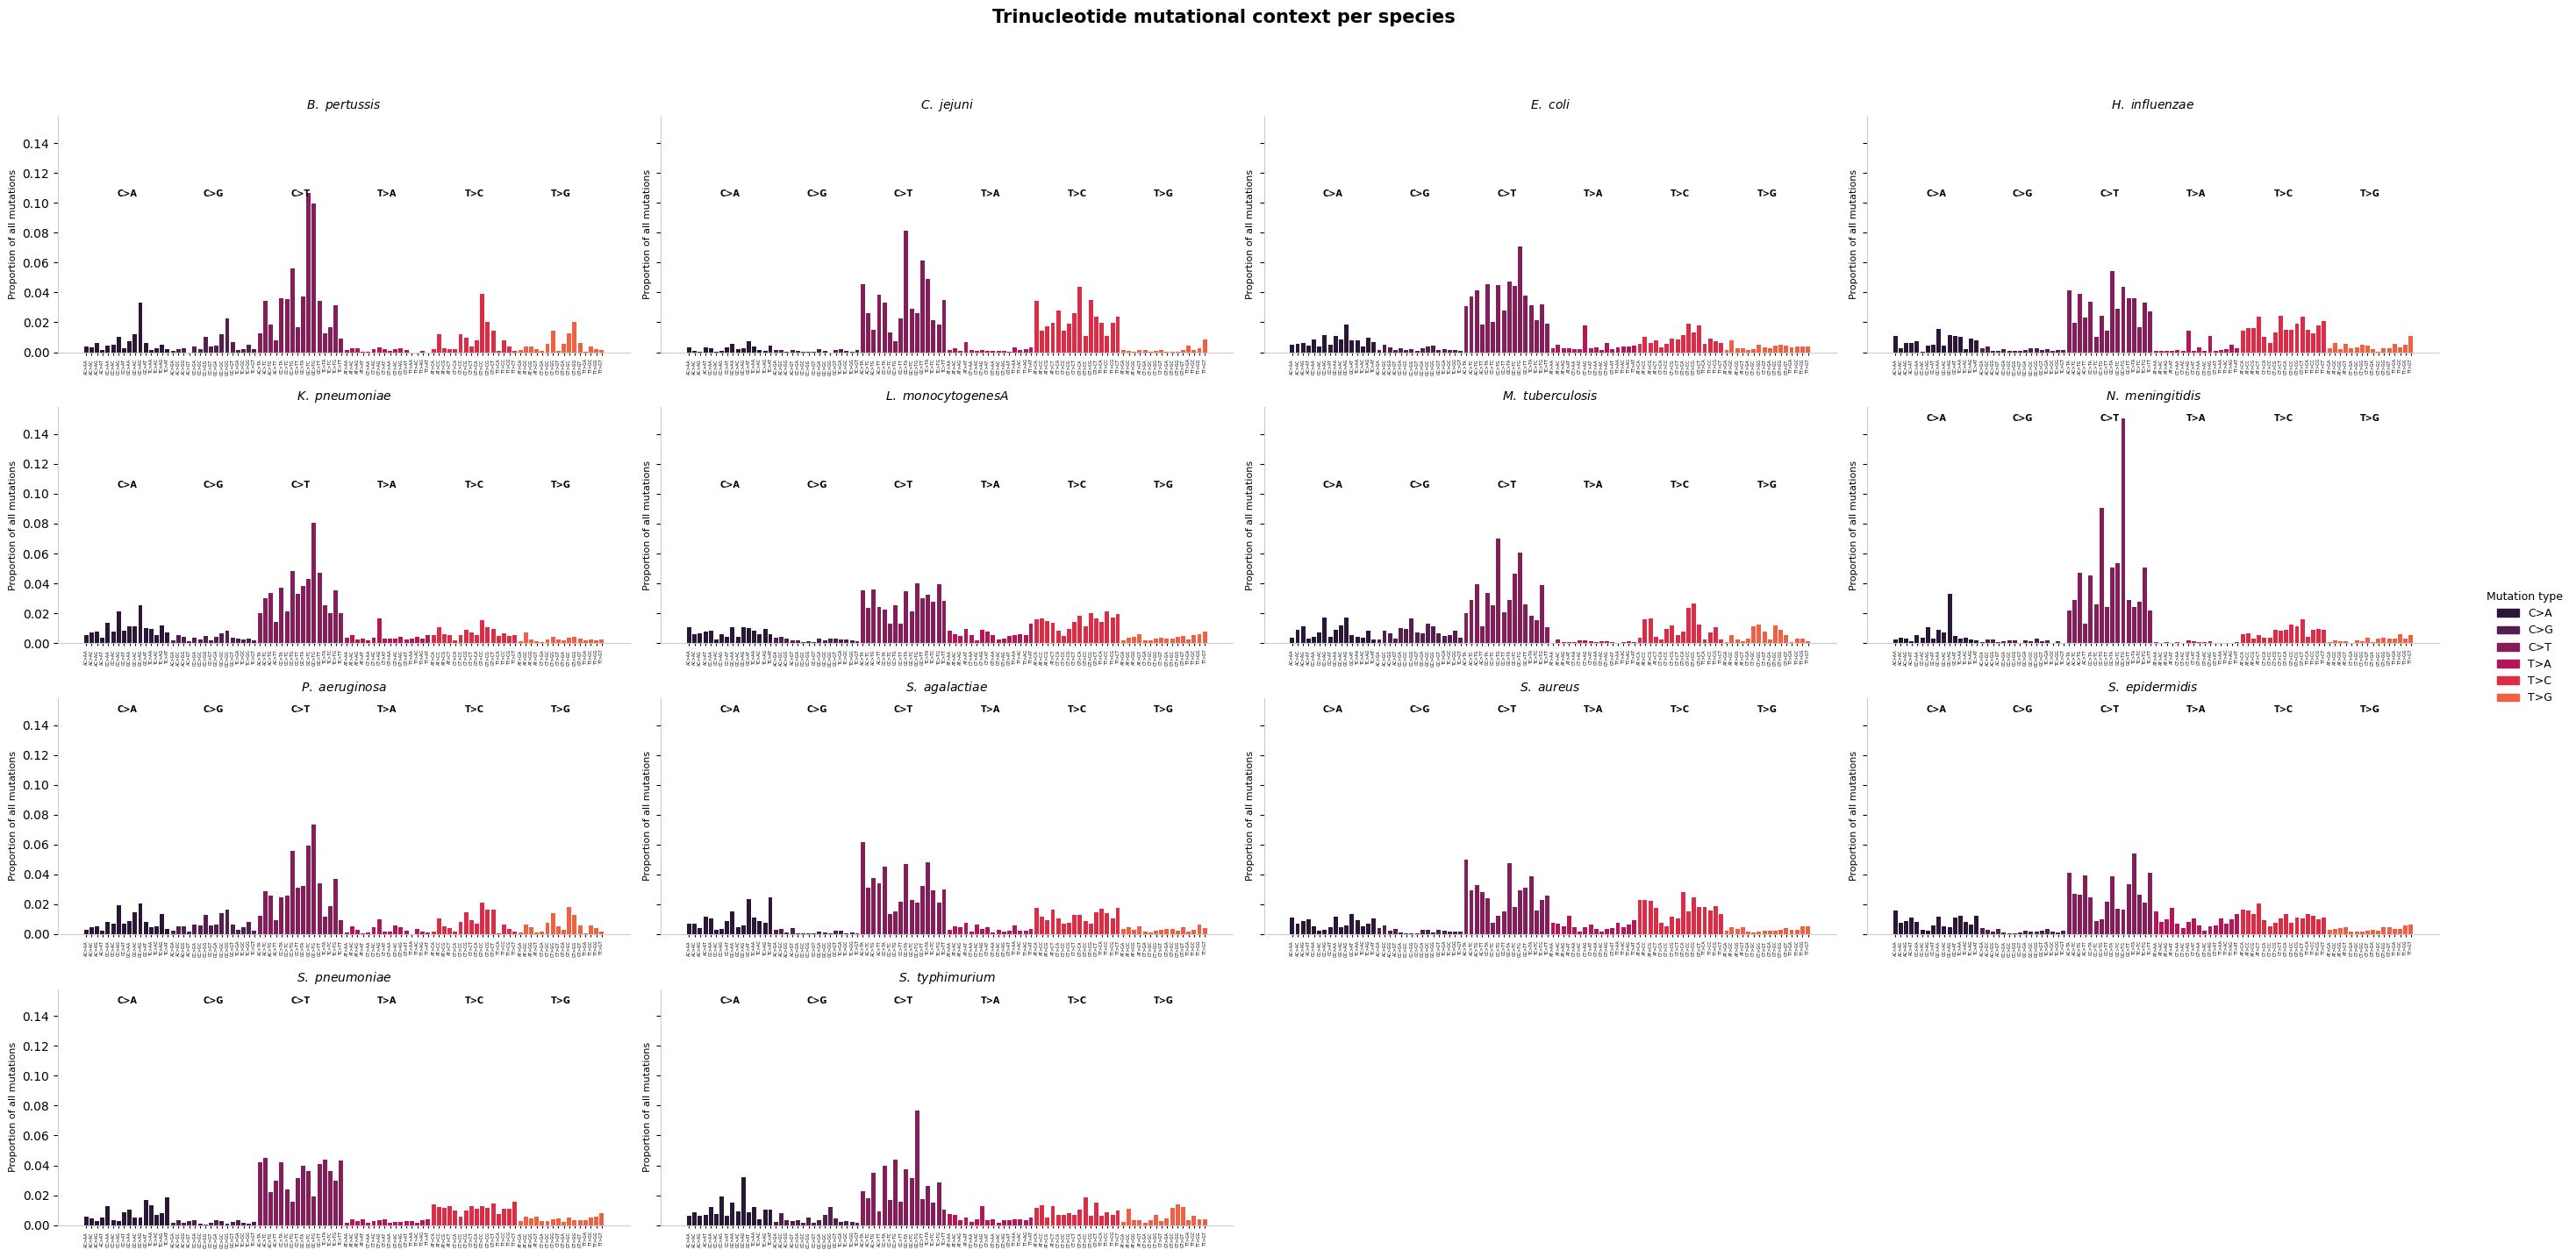

Saved: /home/jovyan/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/mut_signatures/trinucleotide_context.png


In [75]:
#extra - trinucleotide plot - mutation rates without enrichment data


#######
# Trinuc plot 

trinuc_colours = []
for mut in MUTATION_TYPES:
    trinuc_colours.extend([MUT_COLOURS[mut]] * 16)

#same process as before
species_list_trinuc = sorted(trinuc_df["species"].unique())
n_species_t = len(species_list_trinuc)
n_cols_t    = min(4, n_species_t)
n_rows_t    = int(np.ceil(n_species_t / n_cols_t))

fig2, axes2 = plt.subplots(n_rows_t, n_cols_t,
                            figsize=(n_cols_t * 7, n_rows_t * 3.5),
                            sharey=True, facecolor="white")
axes2 = np.atleast_1d(axes2).ravel().tolist()

for i, species in enumerate(species_list_trinuc):
    ax    = axes2[i]
    ax.set_facecolor("white")

    # Sum genic and intergenic  per trinucleotide
    sp_df  = trinuc_df[trinuc_df["species"] == species]
    counts = (sp_df.groupby("trinucleotide")["mutation_count"]
              .sum()
              .reindex(trinuc_context, fill_value=0))
    total  = counts.sum()
    props  = counts / total if total > 0 else counts

    ax.bar(range(96), props.values, color=trinuc_colours, width=0.8)

    genus          = species[0].upper()
    rest           = species[1:]
    formatted_name = f"$\\it{{{genus}.\\ {rest}}}$"
    ax.set_title(formatted_name, fontsize=10, pad=6)
    ax.set_xticks(range(96))
    ax.set_xticklabels(
        [c.replace("[", "").replace("]", "") for c in trinuc_context],
        rotation=90, fontsize=3.5
    )
    ax.set_ylabel("Proportion of all mutations", fontsize=8)

    for block in range(1, 6):
        ax.axvline(block * 16 - 0.5, color="white", linewidth=1.5, zorder=3)

    for b_idx, mut in enumerate(MUTATION_TYPES):
        centre = b_idx * 16 + 7.5
        ax.text(centre, ax.get_ylim()[1] * 0.97, mut,
                ha="center", va="top", fontsize=7,
                fontweight="bold", color="black")

    ax.tick_params(axis="x", length=2)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

for j in range(n_species_t, len(axes2)):
    axes2[j].set_visible(False)

legend_handles2 = [mpatches.Patch(color=MUT_COLOURS[m], label=m)
                   for m in MUTATION_TYPES]
fig2.legend(handles=legend_handles2, title="Mutation type",
            bbox_to_anchor=(1.01, 0.5), loc="center left",
            fontsize=9, title_fontsize=9, frameon=False)
fig2.suptitle("Trinucleotide mutational context per species\n",
              fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
out_path2 = os.path.join(output, "trinucleotide_context.png")
plt.savefig(out_path2, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {out_path2}")